# CommonLID Language Extension: CLD2 Evaluation

Analysis of experiments extending CLD2's language coverage to all 109 CommonLID benchmark languages.
Goal: maximize **macro F1** and **micro F1** while reaching **100% language coverage**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load experiment results
df = pd.read_csv("results_lid.tsv", sep="\t")
for col in ["macro_f1", "micro_f1", "coverage"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Load per-language results
lang_df = pd.read_csv("data/commonlid/results/per_language.tsv", sep="\t")

# Load confusion matrix
conf_df = pd.read_csv("data/commonlid/results/confusion.tsv", sep="\t")

print(f"Experiments: {len(df)}")
print(f"Languages evaluated: {len(lang_df[lang_df['n_samples'] > 0])}")
df

Experiments: 6
Languages evaluated: 90


,commit,macro_f1,micro_f1,coverage,status,description
0,2af08d2,0.4598,0.8694,0.7667,keep,baseline (CLD2 as-is on CommonLID 109 langs)
1,646bdec,0.6391,0.9202,0.7667,keep,switch to full 0122 tables (160+ lang-scripts)
2,763810c,0.6489,0.9216,0.7778,keep,fix ory/gug language code mappings
3,b0849b4,0.6597,0.9241,0.8000,keep,add Aragonese (arg) + Venetian (vec)
4,f2b3d10,0.6616,0.9230,0.8889,keep,add 8 more langs (bik/acf/crh/rcf/gom/bcl/lij/...
5,ab8cf7f,0.6712,0.9230,1.0000,keep,100% coverage: add gcr/kik/ltg/fuv/gcf + 5 more


## Metrics Over Experiments

Track how macro F1, micro F1, and language coverage evolve across experiments.

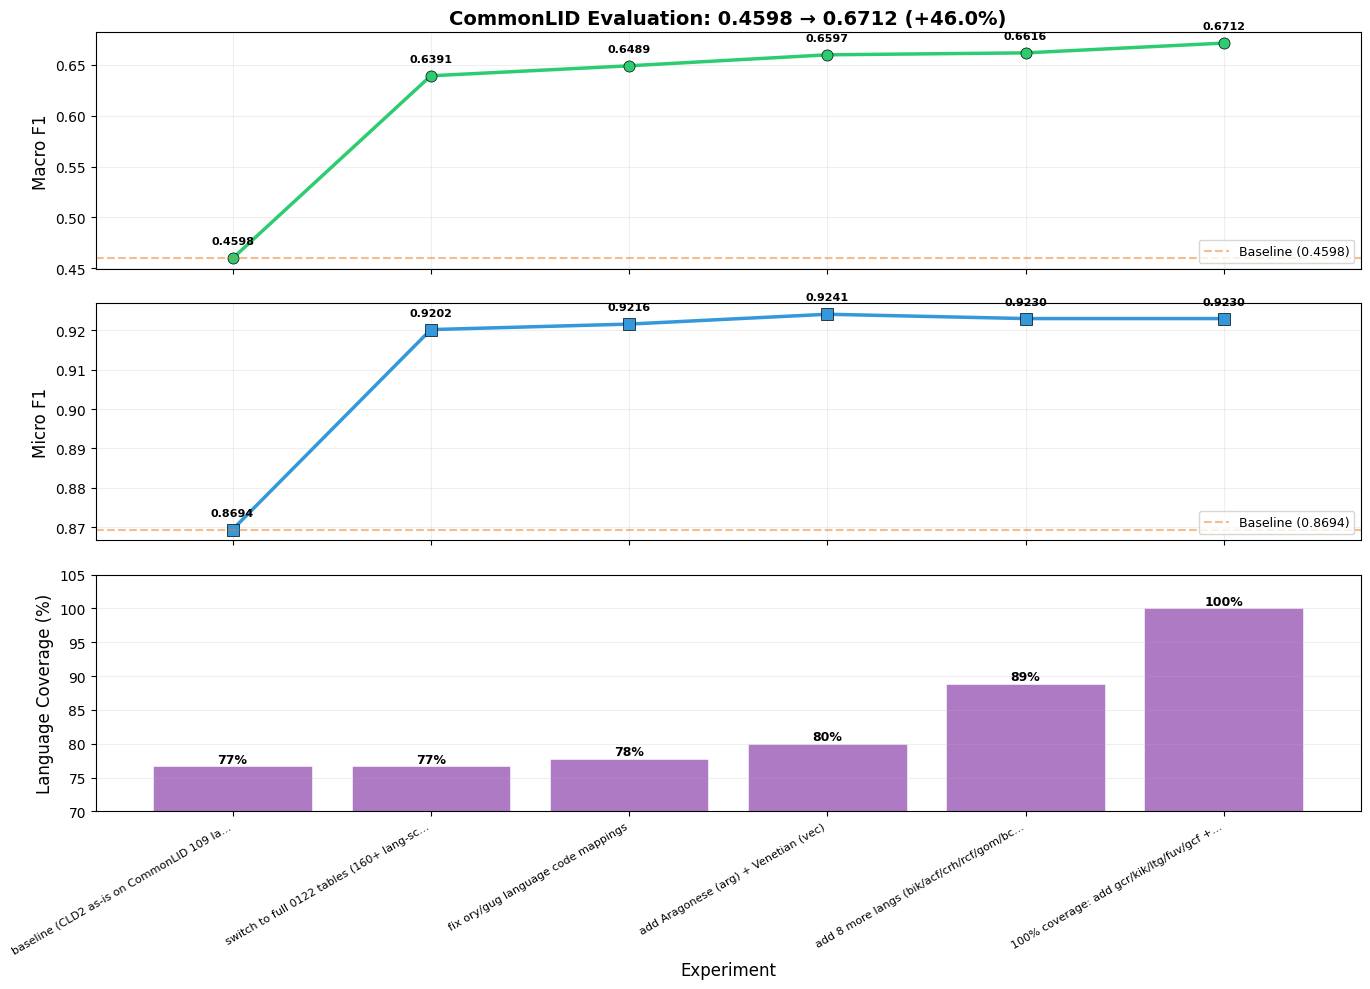

Saved to progress_lid.png


In [2]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

x = range(len(df))
labels = [d[:40] + "..." if len(d) > 40 else d for d in df["description"]]

# Macro F1
ax = axes[0]
ax.plot(x, df["macro_f1"], "o-", color="#2ecc71", linewidth=2.5, markersize=8,
        markeredgecolor="black", markeredgewidth=0.5)
ax.axhline(y=df.iloc[0]["macro_f1"], color="#e67e22", linestyle="--", alpha=0.5,
           label=f"Baseline ({df.iloc[0]['macro_f1']:.4f})")
for i, (xi, v) in enumerate(zip(x, df["macro_f1"])):
    ax.annotate(f"{v:.4f}", (xi, v), textcoords="offset points",
               xytext=(0, 10), ha="center", fontsize=8, fontweight="bold")
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title(f"CommonLID Evaluation: {df.iloc[0]['macro_f1']:.4f} \u2192 {df.iloc[-1]['macro_f1']:.4f} "
             f"(+{(df.iloc[-1]['macro_f1'] - df.iloc[0]['macro_f1']) / df.iloc[0]['macro_f1'] * 100:.1f}%)",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

# Micro F1
ax = axes[1]
ax.plot(x, df["micro_f1"], "s-", color="#3498db", linewidth=2.5, markersize=8,
        markeredgecolor="black", markeredgewidth=0.5)
ax.axhline(y=df.iloc[0]["micro_f1"], color="#e67e22", linestyle="--", alpha=0.5,
           label=f"Baseline ({df.iloc[0]['micro_f1']:.4f})")
for i, (xi, v) in enumerate(zip(x, df["micro_f1"])):
    ax.annotate(f"{v:.4f}", (xi, v), textcoords="offset points",
               xytext=(0, 10), ha="center", fontsize=8, fontweight="bold")
ax.set_ylabel("Micro F1", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

# Coverage
ax = axes[2]
ax.bar(x, df["coverage"] * 100, color="#9b59b6", edgecolor="white", linewidth=0.5, alpha=0.8)
for i, (xi, v) in enumerate(zip(x, df["coverage"])):
    ax.text(xi, v * 100 + 0.5, f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Language Coverage (%)", fontsize=12)
ax.set_ylim(70, 105)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_xlabel("Experiment", fontsize=12)
ax.grid(True, axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("progress_lid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress_lid.png")

## Per-Language F1 Scores

F1 score for each of the 90 CommonLID languages (after normalization), sorted by sample count.
Languages with F1=0 are either unsupported or have too few samples for reliable detection.

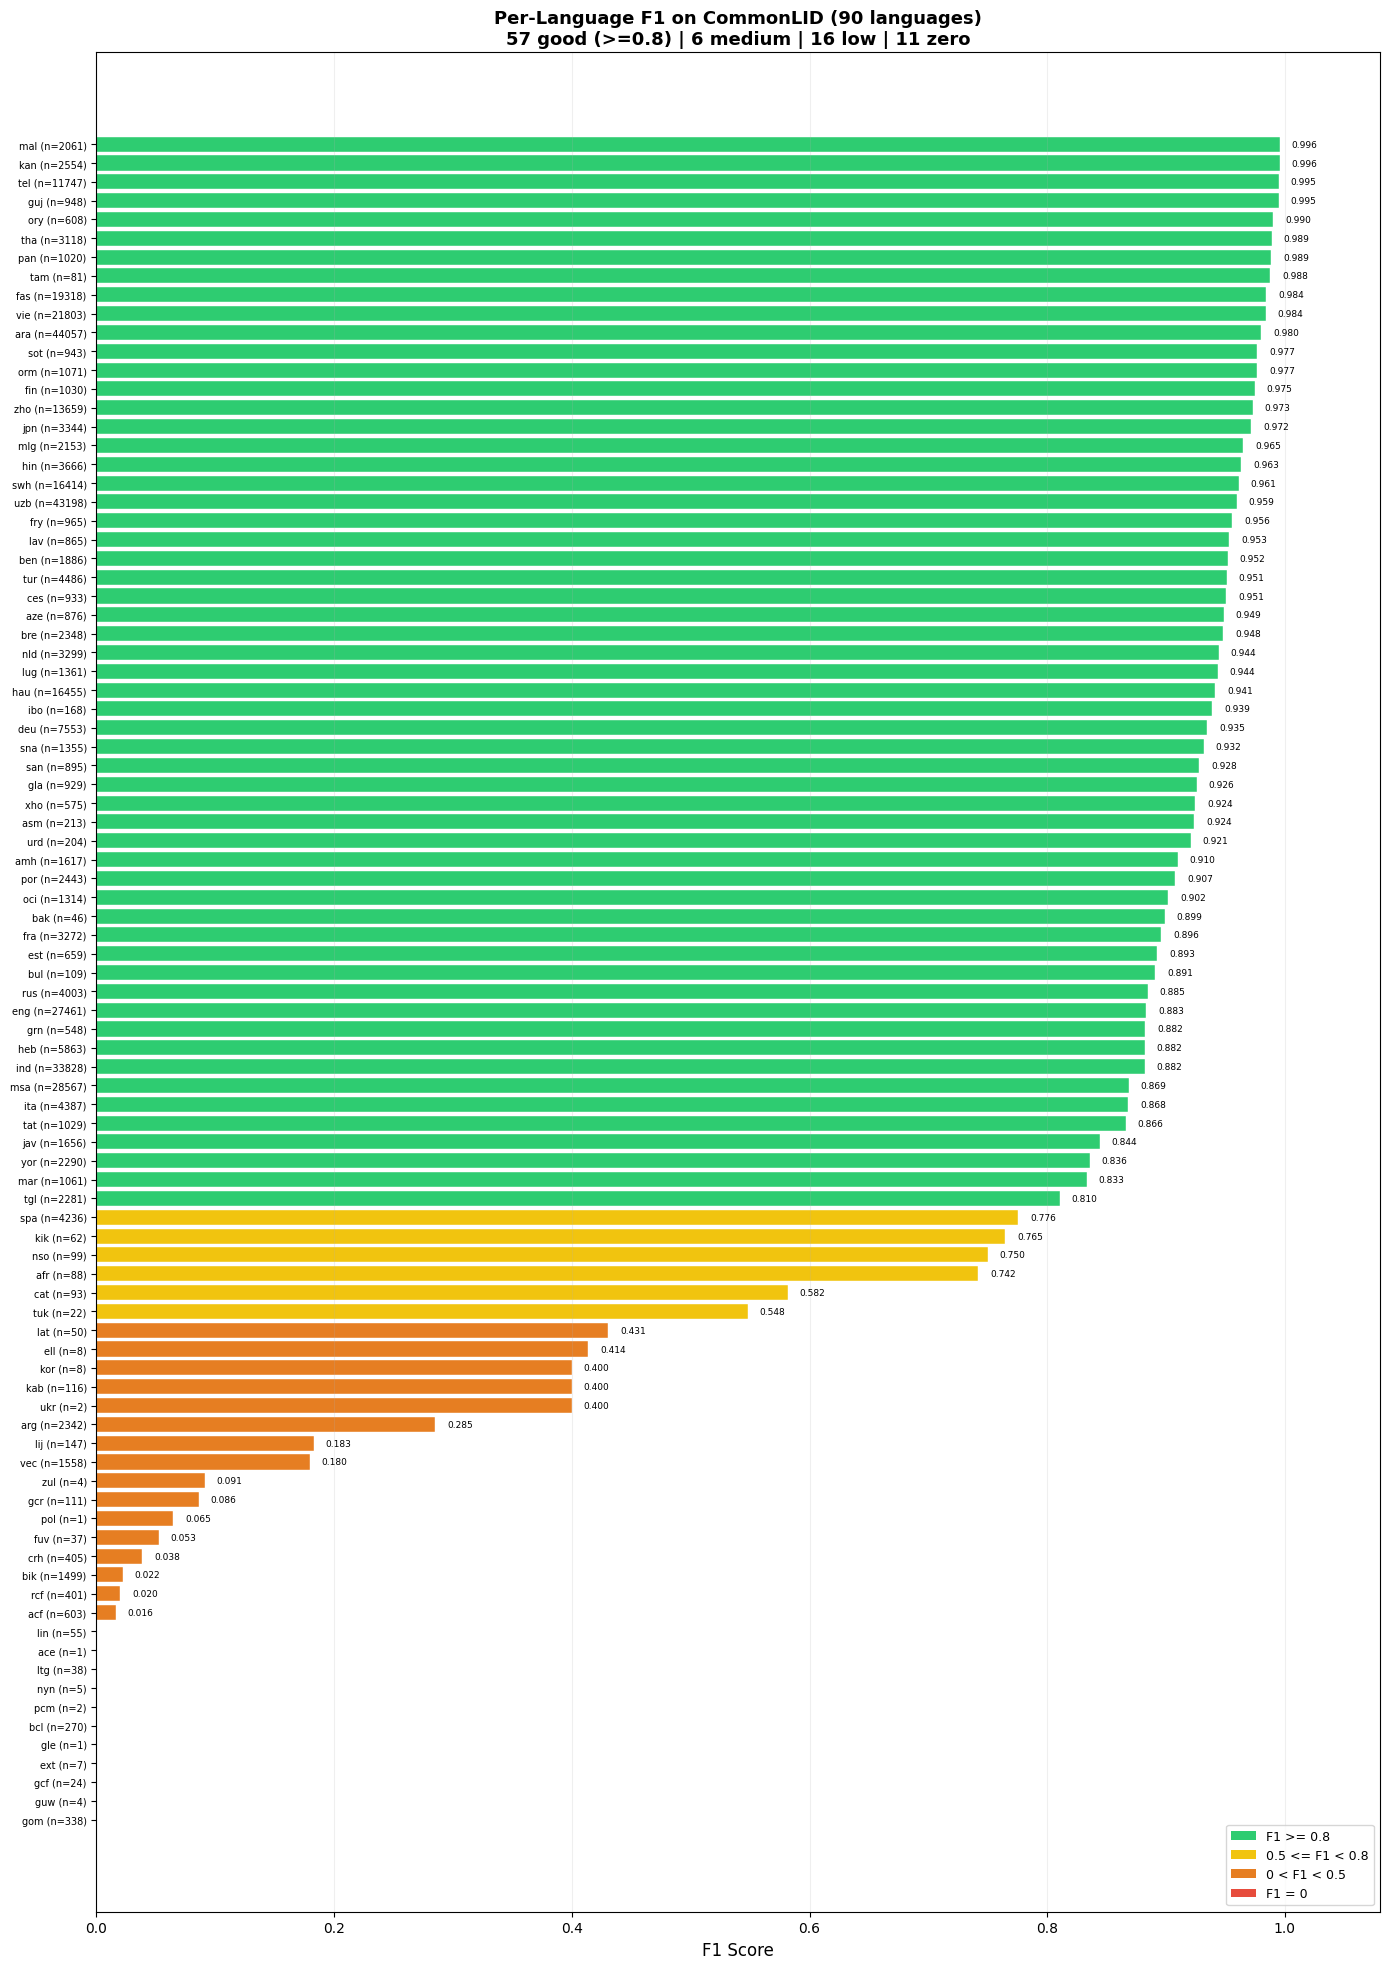

Saved to perlang_f1.png


In [3]:
# Filter to languages with >0 samples in ground truth
gt = lang_df[lang_df["n_samples"] > 0].copy()
gt = gt.sort_values("f1", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, max(12, len(gt) * 0.22)))

colors = []
for _, row in gt.iterrows():
    if row["f1"] == 0:
        colors.append("#e74c3c")
    elif row["f1"] < 0.5:
        colors.append("#e67e22")
    elif row["f1"] < 0.8:
        colors.append("#f1c40f")
    else:
        colors.append("#2ecc71")

bars = ax.barh(range(len(gt)), gt["f1"], color=colors, edgecolor="white", linewidth=0.3)

# Labels: lang code + sample count
ylabels = [f"{row['lang']} (n={row['n_samples']})" for _, row in gt.iterrows()]
ax.set_yticks(range(len(gt)))
ax.set_yticklabels(ylabels, fontsize=7)

# Value labels
for i, (_, row) in enumerate(gt.iterrows()):
    if row["f1"] > 0:
        ax.text(row["f1"] + 0.01, i, f"{row['f1']:.3f}", va="center", fontsize=6.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="F1 >= 0.8"),
    Patch(facecolor="#f1c40f", label="0.5 <= F1 < 0.8"),
    Patch(facecolor="#e67e22", label="0 < F1 < 0.5"),
    Patch(facecolor="#e74c3c", label="F1 = 0"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

n_good = len(gt[gt["f1"] >= 0.8])
n_mid = len(gt[(gt["f1"] >= 0.5) & (gt["f1"] < 0.8)])
n_low = len(gt[(gt["f1"] > 0) & (gt["f1"] < 0.5)])
n_zero = len(gt[gt["f1"] == 0])

ax.set_xlabel("F1 Score", fontsize=12)
ax.set_title(f"Per-Language F1 on CommonLID ({len(gt)} languages)\n"
             f"{n_good} good (>=0.8) | {n_mid} medium | {n_low} low | {n_zero} zero",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.08)
ax.grid(True, axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("perlang_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to perlang_f1.png")

## Top Confusion Pairs

The most common misclassifications. `und` = CLD2 returned "Unknown" (short/ambiguous text).

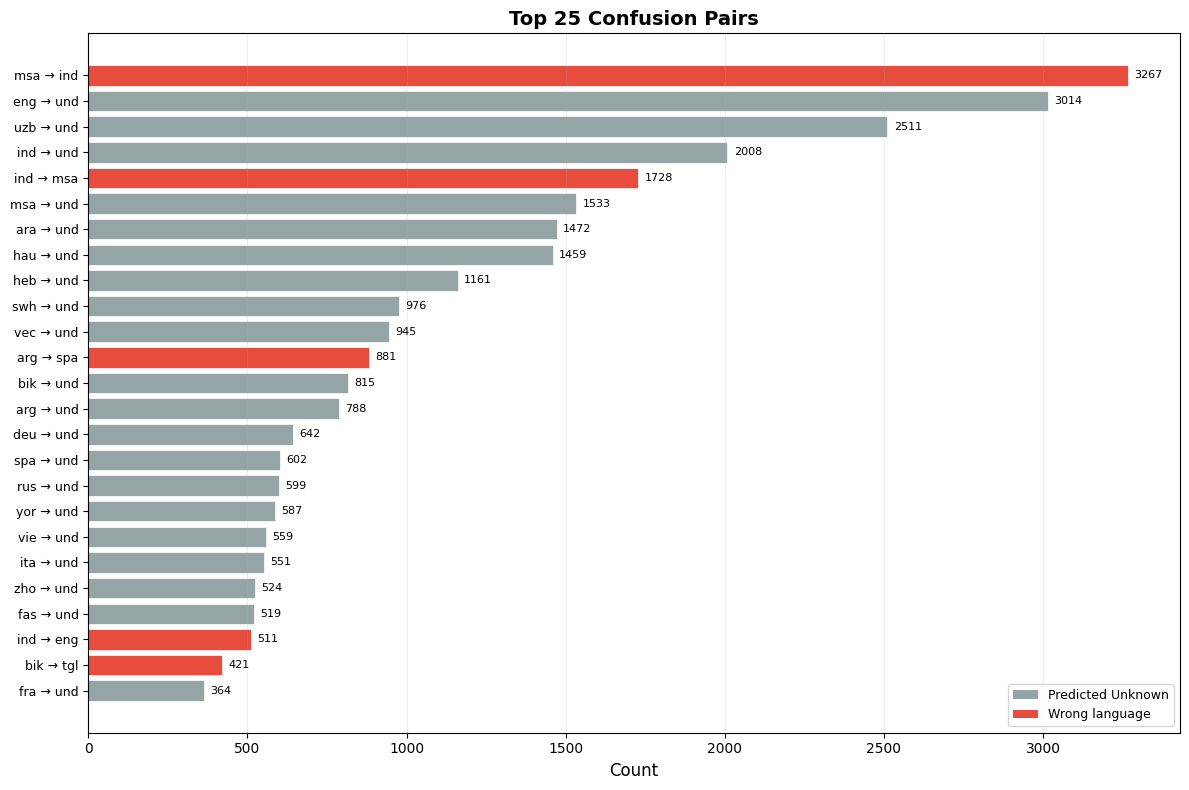

Saved to confusion_lid.png


In [4]:
top_conf = conf_df.head(25).copy()
top_conf["label"] = top_conf["true_lang"] + " \u2192 " + top_conf["pred_lang"]
top_conf = top_conf.iloc[::-1]  # reverse for horizontal bar

fig, ax = plt.subplots(figsize=(12, 8))

colors = ["#95a5a6" if row["pred_lang"] == "und" else "#e74c3c"
          for _, row in top_conf.iterrows()]

ax.barh(range(len(top_conf)), top_conf["count"], color=colors,
        edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(top_conf)))
ax.set_yticklabels(top_conf["label"], fontsize=9)

for i, val in enumerate(top_conf["count"]):
    ax.text(val + 20, i, str(val), va="center", fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#95a5a6", label="Predicted Unknown"),
    Patch(facecolor="#e74c3c", label="Wrong language"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_xlabel("Count", fontsize=12)
ax.set_title("Top 25 Confusion Pairs", fontsize=14, fontweight="bold")
ax.grid(True, axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("confusion_lid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to confusion_lid.png")

## Summary Statistics

In [5]:
gt = lang_df[lang_df["n_samples"] > 0].copy()
total_samples = gt["n_samples"].sum()

print("=" * 60)
print("CommonLID Evaluation Summary")
print("=" * 60)
print(f"Total samples:        {total_samples:,}")
print(f"Total languages:      {len(gt)}")
print(f"Supported languages:  {len(gt[gt['supported'] == 'yes'])}")
print()
print(f"Macro F1:  {df.iloc[0]['macro_f1']:.4f} -> {df.iloc[-1]['macro_f1']:.4f}  "
      f"(+{(df.iloc[-1]['macro_f1'] - df.iloc[0]['macro_f1']):.4f})")
print(f"Micro F1:  {df.iloc[0]['micro_f1']:.4f} -> {df.iloc[-1]['micro_f1']:.4f}  "
      f"(+{(df.iloc[-1]['micro_f1'] - df.iloc[0]['micro_f1']):.4f})")
print(f"Coverage:  {df.iloc[0]['coverage']:.2%} -> {df.iloc[-1]['coverage']:.2%}")
print()

# Top/bottom languages by F1
gt_with_f1 = gt[gt["n_samples"] >= 10].sort_values("f1", ascending=False)
print("Top 10 languages (by F1, n>=10):")
for _, row in gt_with_f1.head(10).iterrows():
    print(f"  {row['lang']:<8} F1={row['f1']:.4f}  P={row['precision']:.3f}  "
          f"R={row['recall']:.3f}  n={row['n_samples']}")

print(f"\nBottom 10 languages (by F1, n>=10):")
for _, row in gt_with_f1.tail(10).iterrows():
    print(f"  {row['lang']:<8} F1={row['f1']:.4f}  P={row['precision']:.3f}  "
          f"R={row['recall']:.3f}  n={row['n_samples']}")

# Biggest error sources
print(f"\nTop 10 confusion pairs:")
for _, row in conf_df.head(10).iterrows():
    print(f"  {row['true_lang']:>5} -> {row['pred_lang']:<5}  {row['count']:>5}")

CommonLID Evaluation Summary
Total samples:        373,230
Total languages:      90
Supported languages:  90

Macro F1:  0.4598 -> 0.6712  (+0.2114)
Micro F1:  0.8694 -> 0.9230  (+0.0536)
Coverage:  76.67% -> 100.00%

Top 10 languages (by F1, n>=10):
  mal      F1=0.9956  P=1.000  R=0.991  n=2061
  kan      F1=0.9955  P=1.000  R=0.991  n=2554
  tel      F1=0.9948  P=1.000  R=0.990  n=11747
  guj      F1=0.9947  P=1.000  R=0.990  n=948
  ory      F1=0.9900  P=1.000  R=0.980  n=608
  tha      F1=0.9889  P=0.996  R=0.982  n=3118
  pan      F1=0.9887  P=0.994  R=0.983  n=1020
  tam      F1=0.9878  P=0.976  R=1.000  n=81
  fas      F1=0.9843  P=1.000  R=0.969  n=19318
  vie      F1=0.9840  P=1.000  R=0.969  n=21803

Bottom 10 languages (by F1, n>=10):
  fuv      F1=0.0526  P=1.000  R=0.027  n=37
  crh      F1=0.0385  P=0.727  R=0.020  n=405
  bik      F1=0.0222  P=0.500  R=0.011  n=1499
  rcf      F1=0.0198  P=1.000  R=0.010  n=401
  acf      F1=0.0164  P=0.833  R=0.008  n=603
  bcl      F1

## New Languages Added

Performance of the 20 new languages added to CLD2 via quadgram table generation.

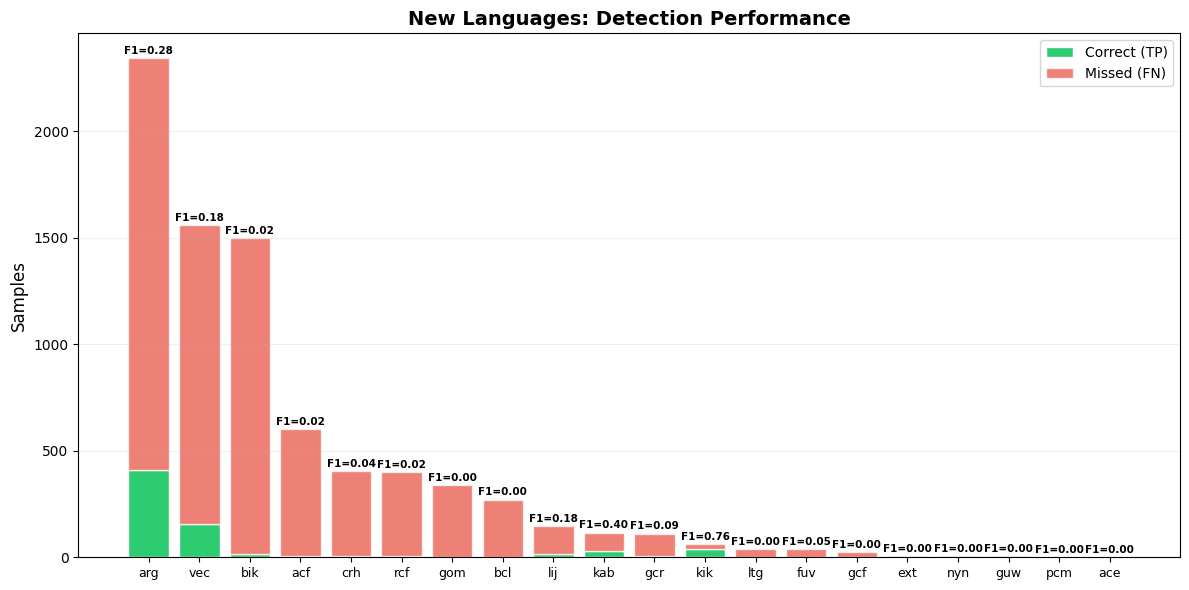

Saved to new_langs.png

Lang    Samples     TP     FP     FN      P      R     F1
-------------------------------------------------------
arg        2342    408    114   1934  0.782  0.174  0.285
vec        1558    155     13   1403  0.923  0.100  0.180
bik        1499     17     17   1482  0.500  0.011  0.022
acf         603      5      1    598  0.833  0.008  0.016
crh         405      8      3    397  0.727  0.020  0.038
rcf         401      4      0    397  1.000  0.010  0.020
gom         338      0      6    338  0.000  0.000  0.000
bcl         270      0      1    270  0.000  0.000  0.000
lij         147     15      2    132  0.882  0.102  0.183
kab         116     29      0     87  1.000  0.250  0.400
gcr         111      5      0    106  1.000  0.045  0.086
kik          62     39      1     23  0.975  0.629  0.765
ltg          38      0      0     38  0.000  0.000  0.000
fuv          37      1      0     36  1.000  0.027  0.053
gcf          24      0      0     24  0.000  0.000

In [6]:
new_langs = ["arg", "vec", "bik", "acf", "crh", "rcf", "gom", "bcl",
             "lij", "kab", "gcr", "kik", "ltg", "fuv", "gcf",
             "ext", "nyn", "guw", "pcm", "ace"]

new_df = lang_df[lang_df["lang"].isin(new_langs) & (lang_df["n_samples"] > 0)].copy()
new_df = new_df.sort_values("n_samples", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(new_df))

# Stacked: TP (green), FN (red)
ax.bar(x, new_df["tp"], color="#2ecc71", label="Correct (TP)", edgecolor="white")
ax.bar(x, new_df["fn"], bottom=new_df["tp"], color="#e74c3c",
       label="Missed (FN)", edgecolor="white", alpha=0.7)

# F1 annotations
for i, (_, row) in enumerate(new_df.iterrows()):
    total = row["tp"] + row["fn"]
    ax.text(i, total + 20, f"F1={row['f1']:.2f}", ha="center", fontsize=7.5, fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(new_df["lang"], fontsize=9)
ax.set_ylabel("Samples", fontsize=12)
ax.set_title("New Languages: Detection Performance", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("new_langs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to new_langs.png")

# Table
print(f"\n{'Lang':<6} {'Samples':>8} {'TP':>6} {'FP':>6} {'FN':>6} {'P':>6} {'R':>6} {'F1':>6}")
print("-" * 55)
for _, row in new_df.iterrows():
    print(f"{row['lang']:<6} {row['n_samples']:>8} {row['tp']:>6} {row['fp']:>6} {row['fn']:>6} "
          f"{row['precision']:>6.3f} {row['recall']:>6.3f} {row['f1']:>6.3f}")